##### Citation Network Paper Classification with Cora

Classifies research papers into one of **seven topics** using both paper-word features and citation relationships.

We compare two approaches:

##### | Approach

| Random Forest baseline | Two-layer GCN

##### Dataset: Cora


In this project, we are using a **prebuilt graph dataset called Cora.**

The Cora dataset contains **scientific research papers and the citation relationships between those papers.**

##### How is the dataset represented?

We represent the dataset as a **graph.**

Research Paper A  ─────►  Research Paper B

        ●                       ●

      Node                    Node

#### 1. Install and import packages

In [27]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier

#### 2. Load the Cora citation graph

Planetoid is the PyTorch Geometric dataset wrapper for Cora, CiteSeer, and PubMed [4]. Each paper is a node, each citation is an edge, x contains node features, and y contains topic labels. The provided masks define the train, validation, and test nodes.

In [28]:
from torch_geometric.datasets import Planetoid

dataset= Planetoid(root="data/Planetoid",name="Cora")
data=dataset[0]



In [29]:
print(f"Numbers of Papers (Nodes): {data.num_nodes}")
print(f"Numbers of Citations (Edges): {data.num_edges}")
print(f"Labels per paper : {dataset.num_classes}")
print(f"Features per paper : {dataset.num_node_features}")


Numbers of Papers (Nodes): 2708
Numbers of Citations (Edges): 10556
Labels per paper : 7
Features per paper : 1433


##### 3. Inspect citation-network structure


A node degree is the number of edges connected to a paper. Degree is a simple graph feature: highly connected papers may be more central to their topic, although degree alone is not enough for classification.

In [30]:
topic_counts=pd.Series(data.y.numpy()).value_counts().sort_index()
topic_counts

0    351
1    217
2    418
3    818
4    426
5    298
6    180
Name: count, dtype: int64

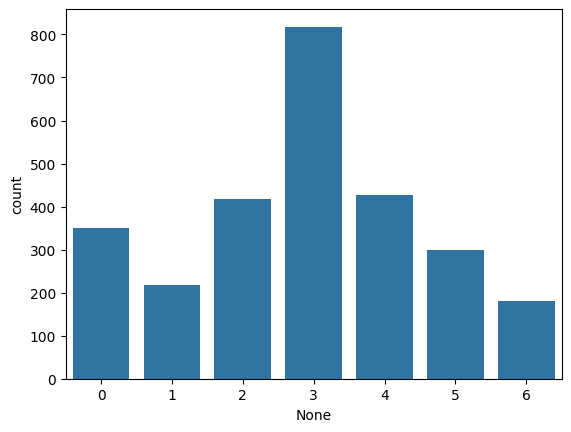

In [31]:
sns.barplot(x=topic_counts.index,y=topic_counts)
plt.show()

##### 4. Baseline: TF-IDF-style features plus Random Forest

The Cora features are binary indicators for whether a vocabulary word appears in a paper. TfidfTransformer reweights these columns so that words occurring in many papers receive less emphasis. We then add two easy graph features: degree and log-degree.


This is a fair educational baseline, but it is not a text model trained on raw abstracts. Its purpose is to answer: How well can we classify papers without message passing across the graph

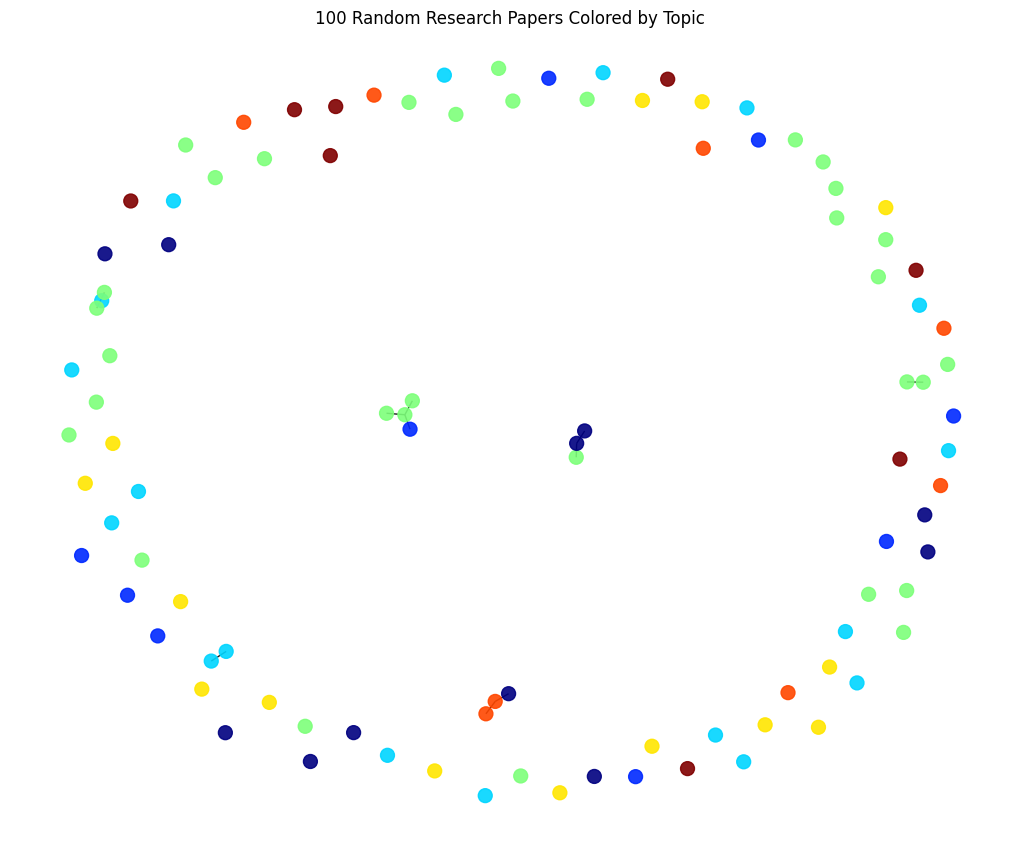

In [32]:
from torch_geometric.utils import to_networkx

import networkx as nx
import random
import matplotlib.pyplot as plt


SEED = 12345

# Convert the PyTorch Geometric data object to a NetworkX graph
G = to_networkx(data, to_undirected=True)

# Select 100 random nodes
random.seed(SEED)
sampled_nodes = random.sample(list(G.nodes()), 100)

# Create a graph using only those nodes
sample_graph = G.subgraph(sampled_nodes)

# Get the topic of each node
node_colors = [
    data.y[node].item()
    for node in sample_graph.nodes()
]

# Create positions for the nodes
pos = nx.spring_layout(sample_graph, seed=SEED)

# Draw the graph
plt.figure(figsize=(10, 8))

nx.draw(
    sample_graph,
    pos,
    node_color=node_colors,
    cmap=plt.cm.jet,
    node_size=100,
    alpha=0.9,
    with_labels=False
)

plt.title("100 Random Research Papers Colored by Topic")
plt.axis("off")
plt.show()

In [33]:
X_binary = data.x.numpy()
y = data.y.numpy()

In [34]:
## Reweight he supplies word indicators. 

from sklearn.feature_extraction.text import  TfidfTransformer

tfidf=TfidfTransformer()

X_tfidf=tfidf.fit_transform(X_binary).toarray()
X_baseline=X_tfidf

train_idx=data.train_mask.numpy() ## training  reseach paper
val_idx=data.val_mask.numpy()
test_idx=data.test_mask.numpy()


X_train,y_train=X_baseline[train_idx],y[train_idx]
X_test,y_test=X_baseline[test_idx],y[test_idx]


rf=RandomForestClassifier(n_estimators=100,max_features="sqrt",class_weight='balanced',random_state=42,n_jobs=1)

rf.fit(X_train,y_train)

rf_pred=rf.predict(X_test)

In [58]:
## evaluation 
from sklearn.metrics import f1_score ,accuracy_score,confusion_matrix

rf_accuracy=accuracy_score(y_test,rf_pred)
rf_f1=f1_score(y_test,rf_pred,average='macro')
print(f"ACCURACY: {accuracy_score (y_test,rf_pred):.4f}")
print(f"Macor-F1:{f1_score (y_test,rf_pred,average='macro'):.4f}")

ACCURACY: 0.5800
Macor-F1:0.5818


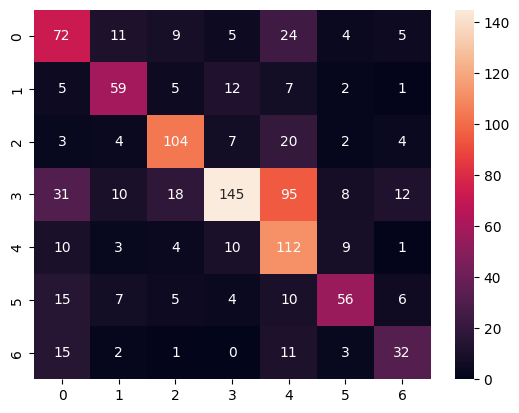

In [36]:
sns.heatmap(confusion_matrix(y_test,rf_pred),annot=True,fmt="d")
plt.show()

##### 5. Advanced model: a simple two-layer GCN

A GCN updates each paper by combining its own features with information from neighboring papers. In this notebook, the model has only two graph-convolution layers, a ReLU activation, and dropout. This keeps the code readable while demonstrating the central idea of graph neural networks.

GCNConv is PyTorch Geometric's implementation of the graph convolution operator [5].

In [37]:
import torch.nn.functional as F
from torch import nn
from torch_geometric.nn import GCNConv
import torch

class SimpleGCN(nn.Module):
  def __init__(self, input_dim,hidden_dim,output_dim,dropout=0.5):
    super().__init__()
    self.conv1 = GCNConv(input_dim, hidden_dim)
    self.conv2 = GCNConv(hidden_dim,output_dim)
    self.dropout = dropout

  def forward(self,x,edge_index):
    x = self.conv1(x,edge_index)
    x = F.relu(x)
    x = F.dropout(x,p=self.dropout,training=self.training)
    x = self.conv2(x,edge_index)
    return x

model = SimpleGCN(
    input_dim = data.num_features,
    hidden_dim = 32,
    output_dim = dataset.num_classes,
)

optimizer=torch.optim.Adam(model.parameters(),lr=0.01)
print(model)

SimpleGCN(
  (conv1): GCNConv(1433, 32)
  (conv2): GCNConv(32, 7)
)


In [55]:
## Training of GCN Model .

def train_one_epoch():
    model.train() ## training 
    optimizer.zero_grad()
    logits = model(data.x, data.edge_index) ## x -> 2708 X 7 
    loss = F.cross_entropy(logits[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()  ## <--- CHANGED THIS LINE FROM print TO return

@torch.no_grad()
def evaluate(mask):
    model.eval()
    logits = model(data.x, data.edge_index) # Pass full edge_index to the model
    predictions = logits.argmax(dim=1)
    accuracy = (predictions[mask] == data.y[mask]).float().mean().item() # Corrected accuracy calculation
    macro_f1 = f1_score(
        data.y[mask].numpy(),
        predictions[mask].numpy(),
        average="macro"
    )
    return accuracy, macro_f1, predictions


In [56]:
evaluate(data.train_mask)

(1.0, 1.0, tensor([3, 4, 4,  ..., 5, 3, 3]))

In [57]:
import copy # Make sure to import this!

losses, train_accuracies, val_accuracies = [], [], []
best_val_accuracy = 0.0
best_state = None

epoch_without_improvement = 0
patience = 20 # Stop if no improvement for this many epochs

for epoch in range(1, 201):
  loss = train_one_epoch()
  train_accuracy, _, _ = evaluate(data.train_mask)
  val_accuracy, _, _ = evaluate(data.val_mask)

  losses.append(loss)
  train_accuracies.append(train_accuracy)
  val_accuracies.append(val_accuracy)

  if val_accuracy > best_val_accuracy:
    best_val_accuracy = val_accuracy
    
    # FIX: Use deepcopy to actually save a snapshot of the best weights!
    best_state = copy.deepcopy(model.state_dict()) 
    epoch_without_improvement = 0

  else:
    epoch_without_improvement += 1

  if epoch_without_improvement >= patience:
    print(f"Early stopping at epoch {epoch}")
    break

  if epoch == 1 or epoch % 10 == 0:
    print(f"Epoch: {epoch:03d} | Loss: {loss:.4f} | Train Acc: {train_accuracy:.4f} | Val Acc: {val_accuracy:.4f} | Best Val Acc: {best_val_accuracy:.4f}")

# Restore the best snapshot
if best_state is not None:
    model.load_state_dict(best_state)

gcn_accuracy, gcn_f1, gcn_pred = evaluate(data.test_mask)

print(f"\nGCN test accuracy: {gcn_accuracy:.3f}")
print(f"GCN test macro-F1: {gcn_f1:.3f}")


Epoch: 001 | Loss: 0.0001 | Train Acc: 1.0000 | Val Acc: 0.7580 | Best Val Acc: 0.7580
Epoch: 010 | Loss: 0.0002 | Train Acc: 1.0000 | Val Acc: 0.7540 | Best Val Acc: 0.7580
Epoch: 020 | Loss: 0.0000 | Train Acc: 1.0000 | Val Acc: 0.7560 | Best Val Acc: 0.7580
Early stopping at epoch 21

GCN test accuracy: 0.776
GCN test macro-F1: 0.770


##### 6. Compare the models

Accuracy is the fraction of correct predictions. Macro-F1 gives every topic equal importance, which is useful when class sizes differ. The exact result can vary slightly across hardware, package versions, and training runs.

In [59]:
results=pd.DataFrame({
    "Model":["Random Forest","GNC"],
    "Accuracy":[rf_accuracy,gcn_accuracy],
    "Macro-F1":[rf_f1,gcn_f1]
})

In [60]:
results

,Model,Accuracy,Macro-F1
0,Random Forest,0.580,0.581814
1,GNC,0.776,0.770157


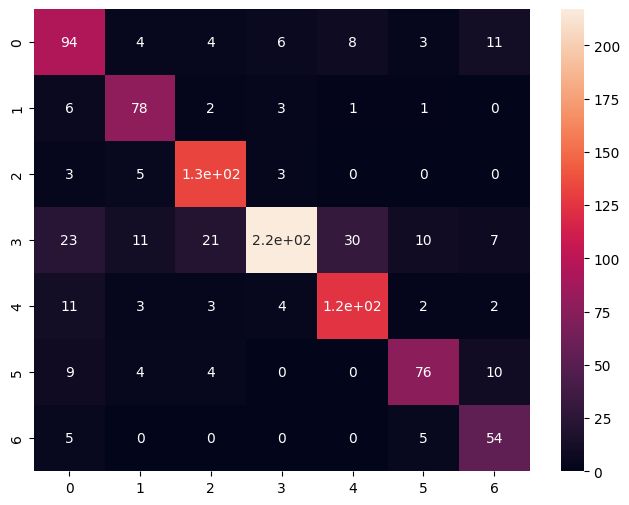

In [63]:
### confsion matrix for GCN model.

plt.figure(figsize=(8,6))
sns.heatmap(
    confusion_matrix(data.y[data.test_mask].numpy(),gcn_pred[data.test_mask].numpy()),annot=True
)

plt.show()

##### 7. What did we learn?

The Random Forest uses each paper's features independently, with degree as a small amount of graph context. The GCN performs message passing, allowing a paper's representation to be influenced by connected papers. When the GCN performs better, the result suggests that citation structure contains useful information about research topics.

However, this is not proof that citations cause topic membership. The graph may contain homophily, dataset artifacts, or information leakage through the standard benchmark split. For a stronger project, try CiteSeer or PubMed, compare different random seeds, report mean and standard deviation over several runs, and test a model using only graph features.

In [73]:
#ONNX -> Open Neural Network Exchange -> Model very fast and optimized.

# ADDED FIX: Force protobuf to use Python to prevent TypeError crashes
import os
os.environ['PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION'] = 'python'

import torch
%pip install onnxscript

#set the model to evaluation mode
model.eval()


#Create dummy input for ONNX export
#The input 'x' has shape [num_nodes, num_features]
#The input 'edge_index' has sahpe[2, edge_index]

x_dummy = data.x
edge_index_dummy = data.edge_index

onnx_file_path = "simple_gcn_cora.onnx"
torch.onnx.export(
    model,                                            #1. Trained Model.
    (x_dummy, edge_index_dummy),                      #2. Model input.
    onnx_file_path,                                   #3. Where to save the ONNX model.
    export_params = True,                             #4. Store the trained parameter weights inside the model file.
    opset_version=18,                                 #5. Changed opset_version to 18 to avoid version conversion issues.
    do_constant_folding=True,                         #6.Whether to execute constant folding for optimation
    input_names=['node_features', 'edge_indices'],    #7. input names
    output_names=['logits'],                          #8. Output names
    dynamic_axes={
        'node_features': {0: 'num_nodes'},            #9.Variable length for num_nodes
        'edge_indices': {1: 'num_edges'}              #10.Variable length for num_edges
    }
)

print(f"Model exported to {onnx_file_path}")


Note: you may need to restart the kernel to use updated packages.
Model exported to simple_gcn_cora.onnx
